# 1. Dutch names generation

Language model implemented with RNN

In [1]:
# %pip install gdown

In [1]:
# %%bash
# gdown 1QDbtPWGQypYxiS4pC_hHBBtbRHk9gEtr
# unzip name_dataset.zip

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("name_dataset/data/NL.csv", header=None, dtype=pd.StringDtype()).dropna()
df

,0,1,2,3
0,Patrick,De Kleijn,M,NL
1,Marco,Visser,M,NL
2,Remon,Griffioen,M,NL
3,Mercedes,Roa,F,NL
4,Odette,Schoonenberg,F,NL
...,...,...,...,...
5429153,Tineke,Waterreus,F,NL
5429154,Kensjero,Marcello,M,NL
5429155,Linde,Caris,F,NL
5429156,Dirk,Van Dijk,M,NL


In [3]:
names_data = np.unique(df.loc[df[0].str.fullmatch("^[a-zA-Z]+$"), 0].to_numpy())
names_data

array(['Aa', 'Aab', 'Aaba', ..., 'Zzp', 'Zzsixth', 'Zzwaan'], dtype=object)

In [4]:
len(names_data)

257736

In [5]:
np.random.choice(names_data, 10)

array(['Ykie', 'Viatie', 'Haniefa', 'Debanjali', 'Lih', 'Tmno', 'Dvora',
       'Sumu', 'Varken', 'Virilla'], dtype=object)

## Dataset

**Processing pipeline:**

chars (tokens) $\to$ indices $\to$ embeddings $\to$ RNN output, hidden $\to$ next char logits

In [45]:
from collections import defaultdict
from transformers import AutoTokenizer

class BPE():
    """Byte-Pair Encoding: Subword-based tokenization algorithm."""
    
    def __init__(self, corpus, vocab_size):
        """Initialize BPE tokenizer."""
        self.corpus = corpus
        self.vocab_size = vocab_size

        # pre-tokenize the corpus into words, BERT pre-tokenizer is used here
        self.tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        self.word_freqs = defaultdict(int)
        self.splits = {}
        self.merges = {}

    def train(self):
        """Train BPE tokenizer."""

        # compute the frequencies of each word in the corpus
        for text in self.corpus:
            words_with_offsets = self.tokenizer.backend_tokenizer.pre_tokenizer.pre_tokenize_str(text)
            new_words = [word for word, offset in words_with_offsets]
            for word in new_words:
                self.word_freqs[word] += 1

        # compute the base vocabulary of all characters in the corpus
        alphabet = []
        for word in self.word_freqs.keys():
            for letter in word:
                if letter not in alphabet:
                    alphabet.append(letter)
        alphabet.sort()

        # add the special token </w> at the beginning of the vocabulary
        vocab = ["</w>"] + alphabet.copy()

        # split each word into individual characters before training
        self.splits = {word: [c for c in word] for word in self.word_freqs.keys()}

        # merge the most frequent pair iteratively until the vocabulary size is reached
        while len(vocab) < self.vocab_size:

            # compute the frequency of each pair
            pair_freqs = self.compute_pair_freqs()

            # find the most frequent pair
            best_pair = ""
            max_freq = None
            for pair, freq in pair_freqs.items():
                if max_freq is None or max_freq < freq:
                    best_pair = pair
                    max_freq = freq

            # merge the most frequent pair
            self.splits = self.merge_pair(*best_pair)
            self.merges[best_pair] = best_pair[0] + best_pair[1]
            vocab.append(best_pair[0] + best_pair[1])
        return self.merges

    def compute_pair_freqs(self):
        """Compute the frequency of each pair."""

        pair_freqs = defaultdict(int)
        for word, freq in self.word_freqs.items():
            split = self.splits[word]
            if len(split) == 1:
                continue
            for i in range(len(split) - 1):
                pair = (split[i], split[i + 1])
                pair_freqs[pair] += freq
        return pair_freqs

    def merge_pair(self, a, b):
        """Merge the given pair."""

        for word in self.word_freqs:
            split = self.splits[word]
            if len(split) == 1:
                continue
            i = 0
            while i < len(split) - 1:
                if split[i] == a and split[i + 1] == b:
                    split = split[:i] + [a + b] + split[i + 2 :]
                else:
                    i += 1
            self.splits[word] = split
        return self.splits


    def tokenize(self, text):
        """Tokenize a given text with trained BPE tokenizer (including pre-tokenization, split, and merge)."""

        pre_tokenize_result = self.tokenizer._tokenizer.pre_tokenizer.pre_tokenize_str(text)
        pre_tokenized_text = [word for word, offset in pre_tokenize_result]
        splits_text = [[l for l in word] for word in pre_tokenized_text]

        for pair, merge in self.merges.items():
            for idx, split in enumerate(splits_text):
                i = 0
                while i < len(split) - 1:
                    if split[i] == pair[0] and split[i + 1] == pair[1]:
                        split = split[:i] + [merge] + split[i + 2 :]
                    else:
                        i += 1
                splits_text[idx] = split
        result = sum(splits_text, [])
        return result


In [49]:
a = BPE(corpus=names_data.tolist(), vocab_size=1000)
a.train()

a.tokenize("Van Dijk")

['Van', 'D', 'ijk']

In [23]:
import torch.nn as nn
import torch

l = nn.Linear(in_features=2, out_features=16)


conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3)
conv2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3)
X = torch.randn(2)
X.shape

torch.Size([2])

In [15]:
IMG = torch.randn((7, 3, 5, 5))  # B C_in H W

In [27]:
from torch.distributions.categorical import Categorical

In [33]:
logits = torch.tensor([[1, 1, 1]])

I --> C_i

I --> cnn(I) --> h_I --> Embed_image_h
Caption (text) --> Tokenizer(text) --> Vocabulary

In [34]:
torch

<module 'torch' from '/home/fvelikon/miniconda3/envs/nlp/lib/python3.9/site-packages/torch/__init__.py'>

In [35]:
Categorical(logits=logits[:, -1:]).sample()

tensor([0])

In [17]:
conv(IMG).shape

torch.Size([7, 1, 3, 3])

In [25]:
IMG_2 = torch.randn((3, 5, 5)) #.unsqueeze(0)  # B C_in H W
IMG_2.shape

torch.Size([3, 5, 5])

In [26]:
conv2(conv(IMG_2))

tensor([[[0.0526]]], grad_fn=<SqueezeBackward1>)

In [10]:
l(X)

tensor([-0.0295, -0.6826,  0.0855,  0.0417, -0.5957, -0.6428, -0.1267,  0.0928,
         1.3230,  0.9818, -0.1182, -0.9923, -0.9139, -0.6162, -0.8190,  0.9629],
       grad_fn=<ViewBackward0>)

In [8]:
l(X[1:5]).shape

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x1 and 2x16)

In [16]:
from nltk.tokenize import WordPunctTokenizer, Str
from itertools import chain
from typing import Iterable, Union, Optional
from collections import Counter
import torch

tokenizer = WordPunctTokenizer()

class VocabPseudoVectorized:
    def __init__(self, train_data: Iterable[str],
                 unk_label: str = "<unk>",
                 bos_label: str = "<bos>",
                 eos_label: str = "<eos>",
                 pad_label: str = "<pad>",
                 unk_cutoff: int = 20):
        raw_counts = Counter(train_data)
        for token, frequency in tuple(raw_counts.items()):
            if frequency >= unk_cutoff:
                continue
            raw_counts.pop(token)
        remaining_tokens = list(raw_counts.keys())
        # add special tokens:
        remaining_tokens[0:0] = [pad_label, bos_label, eos_label, unk_label]

        self._token2idx = {
            token: id_ for id_, token in enumerate(remaining_tokens)
        }
        self._idx2token = {
            id_: token for id_, token in enumerate(remaining_tokens)
        }

    def _fetch_index(self, item: str):
        return self._token2idx.get(item, 0)

    def __getitem__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        if isinstance(item, Iterable) and not isinstance(item, str):
            return list(map(self.__getitem__, item))
    
        return self._fetch_index(item)

    def __call__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        return self[item]

    def __len__(self, ):
        return len(self._token2idx)

    def __contains__(self, item):
        return item in self._token2idx

    def lookup(self, item: Union[str, Iterable[str]]):
        result = []
        if isinstance(item, str):
            return self[item]
        for x in item:
            result.append(self.lookup(x))
        return result

    def get_itos(self, items: Optional[Iterable[str]]=None):
        if items is None:
            return self._idx2token
        if isinstance(items, torch.Tensor):
            items = items.detach().cpu().tolist()
        return [self._idx2token[i] for i in items]

In [24]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output
from torch.utils.data import Dataset, DataLoader
from collections import Counter


plt.rcParams.update({'font.size': 14})
sns.set_style('whitegrid')


class NamesDataset(Dataset):
    def __init__(self, names):
        self.names = names
        self.specials = ['<pad>', '<bos>', '<eos>']
        self.vocab = VocabPseudoVectorized(train_data=chain(*map(tokenizer.tokenize, names)))
        print(f"{len(self.vocab)=}")
        self.itos = self.vocab.get_itos()
        self.pad_index = self.vocab['<pad>']
        self.bos_index = self.vocab['<bos>']
        self.eos_index = self.vocab['<eos>']
        self.max_len = max(len(name) for name in names) + 2

    def __len__(self):
        return len(self.names)

    def str_to_idx(self, chars):
        return [self.vocab[char] for char in chars]
    
    def idx_to_str(self, idx):
        return [self.itos[index] for index in idx]
    
    def encode(self, chars):
        chars = ['<bos>'] + list(chars) + ['<eos>']
        return self.str_to_idx(chars)
        
    def decode(self, idx):
        chars = self.idx_to_str(idx)
        return ''.join(char for char in chars if char not in self.specials)

    def __getitem__(self, item):
        encoded = self.encode(self.names[item])
        padded = torch.full((self.max_len, ), self.pad_index, dtype=torch.int64)
        padded[:len(encoded)] = torch.tensor(encoded)
        return padded, len(encoded)

In [25]:
dataset = NamesDataset(names_data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

len(self.vocab)=4


In [29]:
from tokenizers import BPE

In [ ]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, processors

# Initialize a tokenizer
tokenizer = Tokenizer(models.BPE())

# Customize pre-tokenization and decoding
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tokenizer.decoder = decoders.ByteLevel()
tokenizer.post_processor = processors.ByteLevel(trim_offsets=True)

trainer = trainers.BpeTrainer(
    vocab_size=20000,
    min_frequency=2,
    initial_alphabet=pre_tokenizers.ByteLevel.alphabet()
)
tokenizer.train([
    "./path/to/dataset/1.txt",
    "./path/to/dataset/2.txt",
    "./path/to/dataset/3.txt"
], trainer=trainer)

In [47]:
list(chain(*map(tokenizer.tokenize, names_data)))

['Aa',
 'Aab',
 'Aaba',
 'Aabaa',
 'Aabaha',
 'Aabbasy',
 'Aabbcc',
 'Aabe',
 'Aabed',
 'Aaber',
 'Aabharan',
 'Aabhas',
 'Aabia',
 'Aabid',
 'Aabier',
 'Aabir',
 'Aabm',
 'Aabou',
 'Aabs',
 'Aabush',
 'Aaby',
 'Aac',
 'Aacchh',
 'Aachie',
 'Aachik',
 'Aachir',
 'Aachour',
 'Aachthoven',
 'Aaco',
 'Aacount',
 'Aacxon',
 'Aad',
 'Aadam',
 'Aadan',
 'Aadarsh',
 'Aadc',
 'Aadel',
 'Aadels',
 'Aadem',
 'Aaden',
 'Aadenannie',
 'Aadenelly',
 'Aadeninge',
 'Aadesh',
 'Aadgerda',
 'Aadi',
 'Aadiam',
 'Aadigital',
 'Aadil',
 'Aadina',
 'Aadipree',
 'Aadis',
 'Aadit',
 'Aaditya',
 'Aadjan',
 'Aadjdjd',
 'Aadje',
 'Aadjo',
 'Aadjuh',
 'Aadjuhb',
 'Aadkriti',
 'Aadleeuw',
 'Aadlenie',
 'Aadnee',
 'Aadnis',
 'Aadool',
 'Aadriaan',
 'Aadriano',
 'Aadt',
 'Aadtje',
 'Aaed',
 'Aaeng',
 'Aaeron',
 'Aaf',
 'Aafag',
 'Aafenfre',
 'Aaff',
 'Aaffi',
 'Aaffien',
 'Aaffiena',
 'Aafi',
 'Aafida',
 'Aafie',
 'Aafien',
 'Aafiena',
 'Aafina',
 'Aafje',
 'Aafjeelisabeth',
 'Aafjohn',
 'Aafke',
 'Aafkedekkers',
 

In [20]:
dataset.vocab._token2idx

{'<pad>': 0, '<bos>': 1, '<eos>': 2, '<unk>': 3}

In [7]:
for names, _ in dataloader:
    break

# 0 - <pad> - paddint token
# 1 - <bos> - beginning of a sequence
# 2 - <eos> - end of a sequence
names[:4]

tensor([[ 1, 27,  5,  4,  6, 17,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 41, 11, 12, 30,  6,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 25,  3, 30,  5,  4, 11,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 43,  7,  4,  6, 17,  5,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

## Generator model

Embedding + RNN + Linear head

In [28]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [9]:
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.distributions.categorical import Categorical


class Generator(nn.Module):
    def __init__(self, dataset, embed_dim=32, hidden_dim=32, max_len=None):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=len(dataset.vocab), embedding_dim=embed_dim,
                                      padding_idx=dataset.pad_index)
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, len(dataset.vocab))
        self.dataset = dataset
        self.max_len = dataset.max_len if max_len is None else max_len

    def forward(self, tokens, lengths):
        '''
        B - batch size
        L - sequence length
        E - embedding dim
        H - hidden dim
        V - vocab size
        '''
        # tokens: (B, L)
        embeds = self.embedding(tokens)
        # embeds: (B, L, E) in padded form
        packed_embeds = pack_padded_sequence(embeds, lengths, batch_first=True, enforce_sorted=False)
        outputs, hidden = self.rnn(packed_embeds)
        # output: (B, L, H), hidden: (B, H) in packed form
        outputs, lengths = pad_packed_sequence(outputs, batch_first=True)
        logits = self.linear(outputs)
        # logits: (B, L, V)
        return logits

    @torch.no_grad()
    def inference(self, prefix=''):
        # encode prefix
        tokens = self.dataset.encode(prefix)[:-1]
        tokens = torch.tensor(tokens).unsqueeze(0).to(device)

        # generate hidden for prefix
        embeds = self.embedding(tokens)
        output, hidden = self.rnn(embeds)
        logits = self.linear(output)

        # sample new token from logits
        new_tokens = Categorical(logits=logits[:, -1:]).sample()
        tokens = torch.cat([tokens, new_tokens], dim=1)

        # 2 stopping conditions: reaching max len or getting <eos> token
        while tokens.shape[1] < self.max_len:
            if new_tokens.item() == self.dataset.eos_index:
                break

            # process newly obtained token
            embeds = self.embedding(new_tokens)
            output, hidden = self.rnn(embeds, hidden)
            logits = self.linear(output)
            # sample the next token from logits
            new_tokens = Categorical(logits=logits[:, -1:]).sample()
            tokens = torch.cat([tokens, new_tokens], dim=1)

        # decode result to a string
        return self.dataset.decode(tokens.squeeze())

In [10]:
model = Generator(dataset, embed_dim=32, hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_index)

In [11]:
# inference for untrained model - trash
[model.inference('') for _ in range(10)]

['xTAGLB',
 'GoLOlOWFNmGYEITWiLjnWbKEpS',
 'tujoSnRCvmNyprODibhkWwmTOHknr',
 'FOstGXxkMeqNmgY',
 'vwbgfKLtCTrKPGvIROOOsYkGTeMNw',
 'nHbUfIQvANIKxCmZOmXFZCXMMeygQcl',
 'QvTgWyrNpEhUPlecSQfUncuJMpSXzyj',
 'KDVLXQwUkZgnpcEGaaanRkTKoZgeIcG',
 'JCzAr',
 'DyVxtrzO']

## Training

In [12]:
def plot_losses(losses):
    clear_output()
    plt.plot(range(1, len(losses) + 1), losses)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

In [13]:
from tqdm import trange

In [16]:
losses = []
num_epochs = 200

for epoch in trange(1, num_epochs + 1):
    running_loss = 0.0
    model.train()
    for tokens, lengths in dataloader:
        optimizer.zero_grad()
        tokens = tokens[:, :lengths.max()].to(device)
        logits = model(tokens[:, :-1], lengths - 1)
        # logits: (B, L, V), tokens: (B, L) - need to transpose logits
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * tokens.shape[0]
    
    losses += [running_loss / len(dataset)]
    
    if epoch % 10 == 0:
        plot_losses(losses)

100%|██████████| 1/1 [00:53<00:00, 53.14s/it]


In [17]:
# unconditional generation
[model.inference('') for _ in range(10)]

['Unde',
 'Loemini',
 'Saninaia',
 'Eamazki',
 'Bosmattik',
 'Couspa',
 'Rakoupher',
 'Nienia',
 'Tricariacabuli',
 'Grki']

In [18]:
# conditional generation from prefix
[model.inference('Van') for _ in range(10)]

['Vandyu',
 'Vanikana',
 'Vanon',
 'Vantano',
 'Vanckhmerten',
 'Vann',
 'Vanita',
 'Vanney',
 'Vaninabaraij',
 'Vangree']

# 2. Image captioning

In [19]:
# %%bash
# kaggle datasets download -d hsankesara/flickr-image-dataset
# unzip flickr-image-dataset.zip

In [14]:
import os
import pandas as pd
from PIL import Image

In [15]:
captions = pd.read_csv('flickr30k_images/results.csv', sep='\|\ ').dropna()
captions

/tmp/ipykernel_22869/311428869.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  captions = pd.read_csv('flickr30k_images/results.csv', sep='\|\ ').dropna()


,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
...,...,...,...
158910,998845445.jpg,0,A man in shorts and a Hawaiian shirt leans ove...
158911,998845445.jpg,1,"A young man hanging over the side of a boat , ..."
158912,998845445.jpg,2,A man is leaning off of the side of a blue and...
158913,998845445.jpg,3,"A man riding a small boat in a harbor , with f..."


1: Two women sit on a couch while one holds a baby and the other is being handed a dog by another woman .
2: Two women are sitting beside one another , one holding a baby and the other holding a small dog .
3: Several women are on a couch together playing with a baby and a puppy .
4: The ladies are interacting with a baby and a puppy .
5: Baby on a lap meets puppy on a lap .


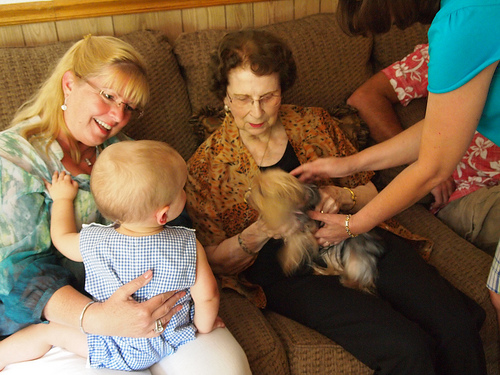

In [16]:
image_file = captions.image_name.sample(1).iloc[0]
for i, caption in enumerate(captions[captions.image_name == image_file].comment):
    print(f'{i + 1}:', caption)
Image.open(os.path.join('flickr30k_images/flickr30k_images', image_file))

In [17]:
image_ids = {k: i for i, k in enumerate(captions.image_name.unique())}
image_list = list(map(lambda x: x[0], sorted(image_ids.items(), key=lambda x: x[1])))
captions['image_id'] = captions.image_name.map(image_ids)

In [18]:
from torch.utils.data import Dataset, DataLoader

class ImagesDataset(Dataset):
    def __init__(self, root, image_list, transform=None):
        super().__init__()
        self.root = root
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, item):
        image_path = os.path.join(self.root, self.image_list[item])
        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image

In [19]:
import torch

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [20]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch import nn

cnn_model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1).eval().to(device)
cnn_model.classifier = nn.Identity()

/home/fvelikon/miniconda3/envs/hse_nlp/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'libc10_cuda.so: cannot open shared object file: No such file or directory'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [21]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.CenterCrop(224),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImagesDataset(root='flickr30k_images/flickr30k_images', image_list=image_list, transform=transform)
dataloader = DataLoader(dataset, num_workers=4, shuffle=False, batch_size=128)

In [26]:
from tqdm.auto import tqdm

image_embeds = []

with torch.no_grad():
    for images in tqdm(dataloader, total=len(dataloader)):
        embeds = cnn_model(images.to(device))
        image_embeds += [embeds.cpu()]

image_embeds = torch.cat(image_embeds, dim=0)

  0%|          | 0/249 [00:00<?, ?it/s]

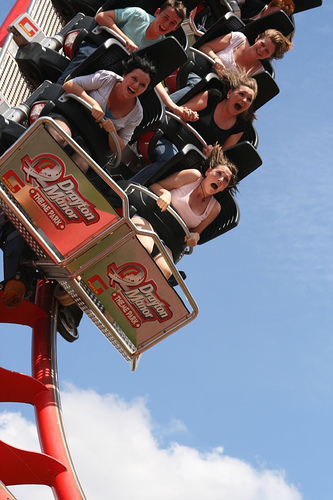

In [22]:
i = 1001
image = Image.open(f'flickr30k_images/flickr30k_images/{image_list[i]}').convert('RGB')
image

In [23]:
captions[captions.image_id == 1001]

,image_name,comment_number,comment,image_id
5005,1315116409.jpg,0,A Drayton Manor Theme Park roller coaster is s...,1001
5006,1315116409.jpg,1,The Drayton Manor Theme Park roller coaster on...,1001
5007,1315116409.jpg,2,While everybody else is having fun on a roller...,1001
5008,1315116409.jpg,3,Several people are riding on a roller coaster ...,1001
5009,1315116409.jpg,4,Family of people right before they crash to th...,1001


In [27]:
image_embeds[i]

tensor([1.5271, 1.4365, 0.1388,  ..., 0.7424, 0.2805, 0.5695])

In [28]:
cnn_model(transform(image).to(device).unsqueeze(0))

tensor([[1.5271, 1.4365, 0.1388,  ..., 0.7424, 0.2805, 0.5695]],
       grad_fn=<ViewBackward0>)

In [30]:
from sklearn.model_selection import train_test_split

train_images, test_images, train_embeds, test_embeds = \
    train_test_split(image_list, image_embeds, test_size=0.25, random_state=42)

train_embeds.shape, test_embeds.shape

(torch.Size([23837, 1280]), torch.Size([7946, 1280]))

In [31]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.CenterCrop(224),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImagesDataset(root='flickr30k_images/flickr30k_images', image_list=image_list, transform=transform)
dataloader = DataLoader(dataset, num_workers=4, shuffle=False, batch_size=128)

In [32]:
train_captions = captions[captions.image_name.isin(train_images)]
test_captions = captions[captions.image_name.isin(test_images)]

train_captions.shape, test_captions.shape

((119184, 4), (39730, 4))

In [33]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

tokenizer = get_tokenizer("basic_english", language="en")
train_captions['tokens'] = train_captions.comment.apply(tokenizer)
test_captions['tokens'] = test_captions.comment.apply(tokenizer)

specials = ['<pad>', '<bos>', '<eos>', '<unk>']
vocab = build_vocab_from_iterator(train_captions.tokens, specials=specials, min_freq=5)
itos = vocab.get_itos()

PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX = vocab['<pad>'], vocab['<bos>'], vocab['<eos>'], vocab['<unk>']
vocab.set_default_index(UNK_IDX)
VOCAB_SIZE = len(vocab)
VOCAB_SIZE

/home/fvelikon/miniconda3/envs/hse_nlp/lib/python3.10/site-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/tmp/ipykernel_22869/90248700.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_captions['tokens'] = train_captions.comment.apply(tokenizer)
/tmp/ipykernel_22869/90248700.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

6829

Train max length: 79


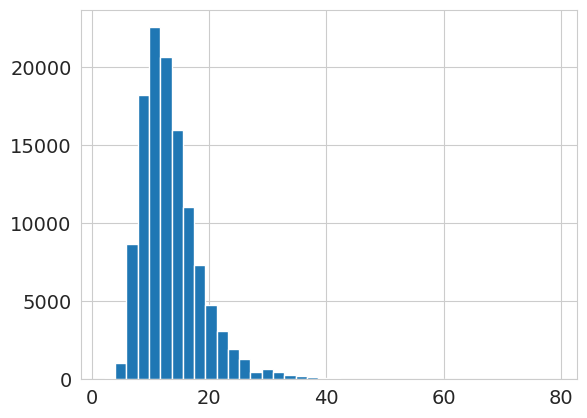

In [34]:
print('Train max length:', train_captions.tokens.apply(len).max())
plt.hist(train_captions.tokens.apply(len), bins=40)
MAX_LENGTH = 40
plt.show()

In [35]:
train_captions

,image_name,comment_number,comment,image_id,tokens
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...,0,"[two, young, guys, with, shaggy, hair, look, a..."
1,1000092795.jpg,1,"Two young , White males are outside near many ...",0,"[two, young, ,, white, males, are, outside, ne..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .,0,"[two, men, in, green, shirts, are, standing, i..."
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .,0,"[a, man, in, a, blue, shirt, standing, in, a, ..."
4,1000092795.jpg,4,Two friends enjoy time spent together .,0,"[two, friends, enjoy, time, spent, together, .]"
...,...,...,...,...,...
158910,998845445.jpg,0,A man in shorts and a Hawaiian shirt leans ove...,31782,"[a, man, in, shorts, and, a, hawaiian, shirt, ..."
158911,998845445.jpg,1,"A young man hanging over the side of a boat , ...",31782,"[a, young, man, hanging, over, the, side, of, ..."
158912,998845445.jpg,2,A man is leaning off of the side of a blue and...,31782,"[a, man, is, leaning, off, of, the, side, of, ..."
158913,998845445.jpg,3,"A man riding a small boat in a harbor , with f...",31782,"[a, man, riding, a, small, boat, in, a, harbor..."


In [36]:
class CaptionsDataset(Dataset):
    def __init__(self, tokens, embeds):
        super().__init__()
        self.tokens = tokens
        self.embeds = embeds

    def __len__(self):
        return len(self.tokens)

    def tokens_to_idx(self, tokens):
        return [vocab[token] for token in tokens]
    
    def idx_to_tokens(self, idx):
        return [itos[index] for index in idx]

    def encode(self, tokens):
        tokens = ['<bos>'] + tokens + ['<eos>']
        return self.tokens_to_idx(tokens)

    def decode(self, idx):
        tokens = self.idx_to_tokens(idx)
        return ' '.join(token for token in tokens if token not in specials)

    def __getitem__(self, item):
        tokens = self.tokens.iloc[item].tokens
        encoded = self.encode(tokens)[:MAX_LENGTH + 2]
        padded = torch.full((MAX_LENGTH + 2, ), PAD_IDX, dtype=torch.int64)
        padded[:len(encoded)] = torch.tensor(encoded)

        image_id = self.tokens.iloc[item].image_id
        return padded, len(encoded), self.embeds[image_id]

In [37]:
train_set = CaptionsDataset(train_captions, image_embeds)
test_set = CaptionsDataset(test_captions, image_embeds)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
embeds_loader = DataLoader(test_embeds, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [38]:
captions_list = []

for image in tqdm(test_images):
    data = test_captions[test_captions.image_name == image]
    captions_list += [data.comment.str.lower().tolist()]

  0%|          | 0/7946 [00:00<?, ?it/s]

In [39]:
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.distributions.categorical import Categorical
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


class CaptionRNN(nn.Module):
    def __init__(self, image_embed_dim, embed_dim=256, hidden_dim=256, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.lstm_layers = lstm_layers
        self.hidden_dim = hidden_dim

        self.image_embed_to_h0 = nn.Sequential(
            nn.Linear(image_embed_dim, lstm_layers * hidden_dim),
            nn.LeakyReLU(0.1),
        )
        self.image_embed_to_c0 = nn.Sequential(
            nn.Linear(image_embed_dim, lstm_layers * hidden_dim),
            nn.LeakyReLU(0.1),
        )

        self.embedding = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embed_dim,
                                      padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                            num_layers=lstm_layers, batch_first=True)
        self.linear = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, VOCAB_SIZE)
        )

    def forward(self, tokens, lengths, image_embeds):
        '''
        B - batch size
        M - lstm layers
        L - sequence length
        I - image embedding dim
        E - embedding dim
        H - hidden dim
        V - vocab size
        '''
        # image_embeds: (B, I)
        B = image_embeds.shape[0]
        h0 = self.image_embed_to_h0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        c0 = self.image_embed_to_c0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        # h0, co: (M, B, H)

        # tokens: (B, L)
        embeds = self.embedding(tokens)
        # embeds: (B, L, E) in padded form

        packed_embeds = pack_padded_sequence(embeds, lengths, batch_first=True, enforce_sorted=False)
        outputs, (h, c) = self.lstm(packed_embeds, (h0, c0))
        # output: (B, L, H) in packed form, (h, c): (M, B, H)
        outputs, lengths = pad_packed_sequence(outputs, batch_first=True)
        logits = self.linear(outputs)
        # logits: (B, L, V)
        return logits

    @torch.no_grad()
    def inference(self, image_embeds):
        self.eval()
        # generate lstm input
        B = image_embeds.shape[0]
        h = self.image_embed_to_h0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        c = self.image_embed_to_c0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        h, c = h.contiguous(), c.contiguous()

        # init tokens with <bos>
        tokens = torch.full((B, 1), BOS_IDX, device=image_embeds.device)
        new_tokens = tokens

        # 2 stopping conditions: reaching max len or getting <eos> token
        while tokens.shape[1] < MAX_LENGTH:
            if ((tokens == EOS_IDX).sum(1) > 0).all():
                break

            # process newly obtained token
            embeds = self.embedding(new_tokens)
            output, (h, c) = self.lstm(embeds, (h, c))
            logits = self.linear(output)

            # get new tokens from logits
            new_tokens = logits.argmax(dim=-1)
            tokens = torch.cat([tokens, new_tokens], dim=1)

        return tokens

In [40]:
# testing
model = CaptionRNN(image_embeds.shape[1])

for tokens, lengths, embeds in train_loader:
    break

tokens = tokens[:, :lengths.max()]
logits = model(tokens, lengths, embeds)
assert logits.shape == (tokens.shape[0], tokens.shape[1], VOCAB_SIZE)

tokens = model.inference(embeds)
train_set.decode(tokens[0])

'mule draws bmw lassos sky sewer smoke passageway passageway wildflowers zombies coast stools necks females button-down winning pads snowball deere bouncing vaulting mariachi pies seagull did seagull vivid bratwurst learning milk asking buns medium-sized netting tent end pancake reviewing'

In [41]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import numpy as np


BLEU_FREQ = 5


def plot_losses(train_losses, test_losses, test_blues):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test', color='springgreen', linewidth=2)
    axs[0].set_ylabel('loss')

    axs[1].plot(BLEU_FREQ * np.arange(1, len(test_blues) + 1), test_blues, label='test',
                color='springgreen', linewidth=2)
    axs[1].set_ylabel('BLEU')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [44]:
from torchmetrics import BLEUScore


def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss = 0.0
    model.train()
    for tokens, lengths, embeds in tqdm(train_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        tokens = tokens[:, :lengths.max()].to(device)

        optimizer.zero_grad()
        logits = model(tokens[:, :-1], lengths - 1, embeds)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * embeds.shape[0]

    train_loss /= len(train_loader.dataset)
    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss = 0.0
    model.eval()
    for tokens, lengths, embeds in tqdm(valid_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        tokens = tokens[:, :lengths.max()].to(device)

        logits = model(tokens[:, :-1], lengths - 1, embeds)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])

        valid_loss += loss.item() * embeds.shape[0]

    valid_loss /= len(valid_loader.dataset)
    return valid_loss


def evaluate_bleu(model, embeds_loader, captions):
    bleu = BLEUScore()
    predictions = []
    model.eval()
    for embeds in tqdm(embeds_loader, desc='Evaluating BLEU'):
        tokens = model.inference(embeds.to(device)).cpu()
        for token_list in tokens:
            predictions += [train_set.decode(token_list)]
    
    return bleu(predictions, captions).item()


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader,
          embeds_loader, captions_list, num_epochs):
    train_losses, valid_losses, valid_blues = [], [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if epoch % BLEU_FREQ == 0:
            valid_bleu = evaluate_bleu(model, embeds_loader, captions_list)
            valid_blues += [valid_bleu]

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        valid_losses += [valid_loss]
        plot_losses(train_losses, valid_losses, valid_blues)

In [45]:
NUM_EPOCHS = 20

model = CaptionRNN(image_embeds.shape[1], dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = None
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

sum(param.numel() for param in model.parameters())

4685485

In [46]:
print(f'Random BLEU: {evaluate_bleu(model, embeds_loader, captions_list):.4f}')

/home/fvelikon/miniconda3/envs/hse_nlp/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `BLEUScore` from `torchmetrics` was deprecated and will be removed in 2.0. Import `BLEUScore` from `torchmetrics.text` instead.
  _future_warning(


Evaluating BLEU:   0%|          | 0/63 [00:00<?, ?it/s]

Random BLEU: 0.0000


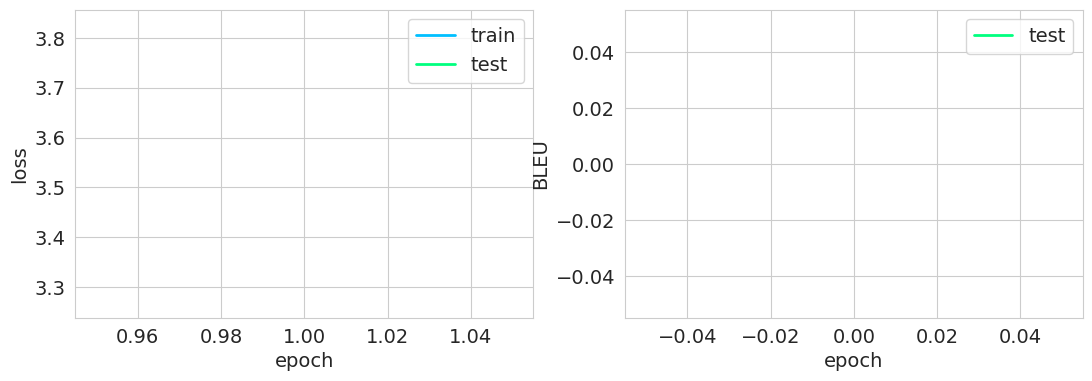

Training 2/20:   0%|          | 0/932 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [47]:
train(model, optimizer, scheduler, criterion, train_loader, test_loader,
      embeds_loader, captions_list, NUM_EPOCHS)

In [ ]:
def caption_random_test_image():
    index = np.random.randint(len(test_images))
    image_file = test_images[index]
    tokens = model.inference(test_embeds[index].unsqueeze(0).to(device)).cpu().squeeze()
    prediction = train_set.decode(tokens)
    print('Prediction:', prediction)

    for i, caption in enumerate(captions[captions.image_name == image_file].comment):
        print(f'GT caption #{i + 1}:', caption)

    return Image.open(os.path.join('flickr30k_images/flickr30k_images', image_file)).convert('RGB')

In [ ]:
caption_random_test_image()

# 3. Code reproducibility

In [ ]:
import torch
import numpy as np
import random

def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
set_random_seed(0xDEADF00D)

In [ ]:
a = nn.Conv2d(1, 1, kernel_size=3, bias=True).to(device)
a.weight, a.bias

In [ ]:
x = torch.randn(1, 1, 5, 5).to(device)
x

In [ ]:
a(x)

In [ ]:
dataloader = DataLoader(torch.arange(20), shuffle=True, num_workers=4, batch_size=3)
for batch in dataloader:
    print(batch)

In [ ]:
set_random_seed(0xDEADF00D)

In [ ]:
a = nn.Conv2d(1, 1, kernel_size=3, bias=True).to(device)
a.weight, a.bias

In [ ]:
x = torch.randn(1, 1, 5, 5).to(device)
x

In [ ]:
a(x)

In [ ]:
dataloader = DataLoader(torch.arange(20), shuffle=True, num_workers=4, batch_size=3)
for batch in dataloader:
    print(batch)